# Prova 2 - NLP - 2025s1

INSTRUÇÕES: Resolva esta prova. Após, transcreva as partes dissertativas das respostas para o Blackboard (CTRL-C / CTRL-V) nos espaços indicados. Por fim, anexe seu notebook como material complementar da Questão 2.

## Rubrica geral da prova

Níveis de aprendizado

* 0 [F] Insuficiente: Falha em atingir todos os requisitos do nível seguinte.
* 2.5 [D] Em desenvolvimento: Identifica o sub-domínio ou a categoria de ferramentas que podem levar a soluções de problemas. Identifica quais são as entradas e saídas de um sistema, e seu significado para o problema. É capaz de resolver problemas usando códigos "template".
* 5.0 [C] Básico: É capaz de argumentar a favor ou contra uma solução usando jargões técnicos, com uso mínimo de metáforas. Usa corretamente métricas de desempenho para avaliar soluções. É capaz de modificar parâmetros de sistema para adequá-los a uma situação específica e avaliar o efeito dessas modificações.
* 7.5 [B] Proficiente: Identifica, usando método científico, os componentes do sistema que levam a gargalos de desempenho. Argumenta corretamente e usando os jargões adequados sobre as limitações das métricas de desempenho, e argumenta sobre o impacto dessas limitações para o problema específico. Cita brevemente formulações matemáticas. Justifica suas principais escolhas com argumentos precisos e/ou com resultados de análises.
* 10 [A] Avançado: Argumenta sobre soluções e sobre suas limitações usando jargões técnicos precisos. Liga claramente os parâmetros do mundo real aos parâmetros matemáticos das formulações. Justifica todas as suas escolhas com argumentos precisos e/ou com resultados de análises.

## Problema

É relativamente comum usarmos embeddings gerados pelo BERT para classificar frases. Em geral, o código para gerar embeddings com BERT se parece com:

    from transformers import BertTokenizer, BertModel
    from tqdm import tqdm
    import numpy as np
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model = BertModel.from_pretrained('bert-base-uncased')
    def get_embeddings(text, model, tokenizer):
        # Tokenize the input text
        inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=512)
        outputs = model(**inputs)
        cls_embedding = outputs.last_hidden_state[0, 0, :]
        return cls_embedding

    embeddings = []
    for i in tqdm(range(len(X))):
        e = get_embeddings(X.iloc[i], model, tokenizer)
        embeddings.append(e.detach().numpy())
    embeddings = np.array(embeddings)
    np.save('bert_embeddings.npy', embeddings)

De acordo com o [artigo do BERT](https://arxiv.org/abs/1810.04805), os embeddings foram treinados, usando um token por palavra, em diversos textos em inglês:

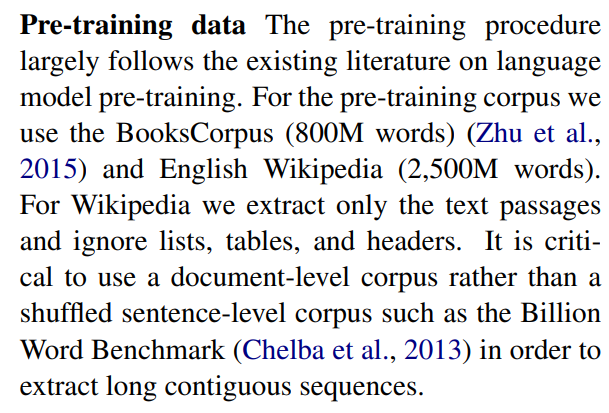

Porém, em lugares que não temos a língua inglesa como língua padrão, gostaríamos de realizar tarefas de classificação em línguas nativas.

Neste trabalho, vamos trabalhar com a classificação de mensagens no twitter sobre o Ibovespa. A ideia de fazer essa classificação é que o Twitter poderia ser uma representação do sentimento geral do mercado (*bullish* ou *bearish* markets). O dataset para isso é o seguinte:

In [1]:
import kagglehub
from pathlib import Path
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("jvbeltra/sentiment-analysis-pt-br-stock-market-tweets")
path = Path(path)
df = pd.read_csv(path / "analise_sentimentos_ibovespa_twitter.csv")
df.head()

100%|██████████| 92.7k/92.7k [00:00<00:00, 399kB/s]

Extracting files...


,post_id,text,created_at,finbertptbr_prediction,gpt_prediction,real_sentiment
0,1818246570069934451,"a partir desse cálculo, para cada empresa do i...",2024-07-30T08:25:38.000000Z,NEUTRAL,NEUTRAL,NEUTRAL
1,1818251106570395982,ibovespa reage às entrelinhas do relatório de ...,2024-07-30T08:43:39.000000Z,NEUTRAL,NEUTRAL,NEUTRAL
2,1818257465793765640,ibovespa em queda de olho na reunião do copom,2024-07-30T09:08:56.000000Z,NEGATIVE,NEGATIVE,NEGATIVE
3,1818262436144669087,esquenta dos mercados \nbom dia!\no ibovespa a...,2024-07-30T09:28:41.000000Z,POSITIVE,NEUTRAL,NEUTRAL
4,1818262819063660642,ibovespa futuro cai na expectativa pelo 1º dia...,2024-07-30T09:30:12.000000Z,NEGATIVE,NEGATIVE,NEGATIVE


Como podemos ver, a tarefa é relacionar o conteúdo da coluna "text" ao rótulo colocado em "real_sentiment". Este dataset em especial já traz predições realizadas por outros modelos (finBertPt e GPT 3.5), que foram usadas em trabalhos anteriores. Ignore essas informações pois não vamos usá-las.

Para extrair embeddings de todos os textos do dataset, podemos usar o seguinte laço:

In [2]:
from transformers import BertTokenizer, BertModel
from tqdm import tqdm
import numpy as np
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
def get_embeddings(text, model, tokenizer):
    # Tokenize the input text
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=512)
    outputs = model(**inputs)
    cls_embedding = outputs.last_hidden_state[0, 0, :]
    return cls_embedding

embeddings = []
for i in tqdm(range(len(df))):
    e = get_embeddings(df.iloc[i]['text'], model, tokenizer)
    embeddings.append(e.detach().numpy())
embeddings = np.array(embeddings)
np.save('bert_embeddings.npy', embeddings)

100%|██████████| 1290/1290 [01:57<00:00, 11.01it/s]


Porém, BERT foi treinado em inglês, e, portanto, talvez haja problemas com o vocabulário em português. Para evitar isso é possível usar a versão multilingual de BERT, que foi treinada em dumps da Wikipedia em várias línguas:

In [3]:
tokenizer_pt = BertTokenizer.from_pretrained('bert-base-multilingual-uncased')
model_pt = BertModel.from_pretrained("bert-base-multilingual-uncased")
embeddings = []
for i in tqdm(range(len(df))):
    e = get_embeddings(df.iloc[i]['text'], model_pt, tokenizer_pt)
    embeddings.append(e.detach().numpy())
embeddings = np.array(embeddings)
np.save('bert_pt_embeddings.npy', embeddings)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\Vinicius Rodrigues\Desktop\Insper\6o Semestre\Natural Language Processing\nlp_course\env\Lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Vinicius Rodrigues\.cache\huggingface\hub\models--bert-base-multilingual-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/672M [00:00<?, ?B/s]

100%|██████████| 1290/1290 [02:02<00:00, 10.56it/s]


Por fim, temos sempre nossa hipótese nula: a de que um sistema com Bag of Words funciona bem o suficiente para nossa tarefa:

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(df['text'], df['real_sentiment'], test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    NEGATIVE       0.77      0.19      0.30        53
     NEUTRAL       0.61      0.74      0.67        98
    POSITIVE       0.71      0.83      0.76       107

    accuracy                           0.67       258
   macro avg       0.70      0.59      0.58       258
weighted avg       0.68      0.67      0.63       258



## Perguntas

### Exercício 1

Por que faz sentido dizer que o BERT multilingue deveria ser uma alternativa melhor que o BERT original para esta tarefa de classificação? Articule sua argumentação tendo em vista a rubrica:


* 0 [F] Insuficiente: Falha em atingir todos os requisitos do nível seguinte.
* 2.5 [D] Em desenvolvimento: Identifica o sub-domínio ou a categoria de ferramentas que podem levar a soluções de problemas. Identifica quais são as entradas e saídas de um sistema, e seu significado para o problema. É capaz de resolver problemas usando códigos "template".
* 5.0 [C] Básico: É capaz de argumentar a favor ou contra uma solução usando jargões técnicos, com uso mínimo de metáforas. Usa corretamente métricas de desempenho para avaliar soluções. É capaz de modificar parâmetros de sistema para adequá-los a uma situação específica e avaliar o efeito dessas modificações.
* 7.5 [B] Proficiente: Identifica, usando método científico, os componentes do sistema que levam a gargalos de desempenho. Argumenta corretamente e usando os jargões adequados sobre as limitações das métricas de desempenho, e argumenta sobre o impacto dessas limitações para o problema específico. Cita brevemente formulações matemáticas. Justifica suas principais escolhas com argumentos precisos e/ou com resultados de análises.
* 10 [A] Avançado: Argumenta sobre soluções e sobre suas limitações usando jargões técnicos precisos. Liga claramente os parâmetros do mundo real aos parâmetros matemáticos das formulações. Justifica todas as suas escolhas com argumentos precisos e/ou com resultados de análises.

É importante relembrar que embora o BERT seja uma ferramenta de elevada complexidade matemática - uma vez que seus embeddings se baseiam numa multiplicidade de variáveis (distribuição estatística, contexto, semântica, etc.) representadas em dimensões de vetor - a metrificação dos parâmetros de cada embedding se baseia enormemente na similaridade de significado entre as palavras e posição relativa no texto. Neste sentido, o BERT original, tendo sido treinado na língua inglesa, não terá, em sua construção, entendimento linguístico das palavras da língua portuguesa, de forma que, quando submetido a treino com uma base em português, acabará por metrificar de maneira incorreta as dimensões correspondentes a contexto e semântica. Desta forma, a única dimensão confiável no modelo seria a distribuição estatística das palavras.

Porém, se voltarmos um pouco, o Bag-of-words já se mostrava relativamente confiável em se tratando de categorizar textos a partir da distribuição estatística das palavras, com a diferença de, para textos pequenos ou médios, exigir um poder de processamento muito menor do que os embeddings do BERT, devido a redução das dimensões das matrizes que compõem o cálculo probabilístico. Assim, usando o BERT original para classificar uma base em português, estaríamos essencialmente usando um Bag-of-words glorificado.

Desta forma, a utilização do BERT multilíngue se torna crucial. Através dele, o BERT estaria treinado para compreender o significado das palavras da língua portuguesa, assim como o significado relativo na construção das frases. Assim, o cálculo dos parâmetros seria mais preciso em todas as dimensões, permitindo que usufruamos de todo o potencial que o BERT é capaz de oferecer - evitando que fiquemos preso à superficialidade da distribuição estatística das palavras relativo ao rótulo.

### Exercício 2

Compare o classificador que usa BERT original com aquele que usa BERT multilingual. De acordo com os resultados de classificação, e com a visualização de embeddings usando TSNE (se quiser, use também PCA), discuta se os argumentos discutidos no exercício 1 se refletiram, de fato, em um aumento de desempenho.

* 0 [F] Insuficiente: Falha em atingir todos os requisitos do nível seguinte.
* 2.5 [D] Em desenvolvimento: Identifica o sub-domínio ou a categoria de ferramentas que podem levar a soluções de problemas. Identifica quais são as entradas e saídas de um sistema, e seu significado para o problema. É capaz de resolver problemas usando códigos "template".
* 5.0 [C] Básico: É capaz de argumentar a favor ou contra uma solução usando jargões técnicos, com uso mínimo de metáforas. Usa corretamente métricas de desempenho para avaliar soluções. É capaz de modificar parâmetros de sistema para adequá-los a uma situação específica e avaliar o efeito dessas modificações.
* 7.5 [B] Proficiente: Identifica, usando método científico, os componentes do sistema que levam a gargalos de desempenho. Argumenta corretamente e usando os jargões adequados sobre as limitações das métricas de desempenho, e argumenta sobre o impacto dessas limitações para o problema específico. Cita brevemente formulações matemáticas. Justifica suas principais escolhas com argumentos precisos e/ou com resultados de análises.
* 10 [A] Avançado: Argumenta sobre soluções e sobre suas limitações usando jargões técnicos precisos. Liga claramente os parâmetros do mundo real aos parâmetros matemáticos das formulações. Justifica todas as suas escolhas com argumentos precisos e/ou com resultados de análises.

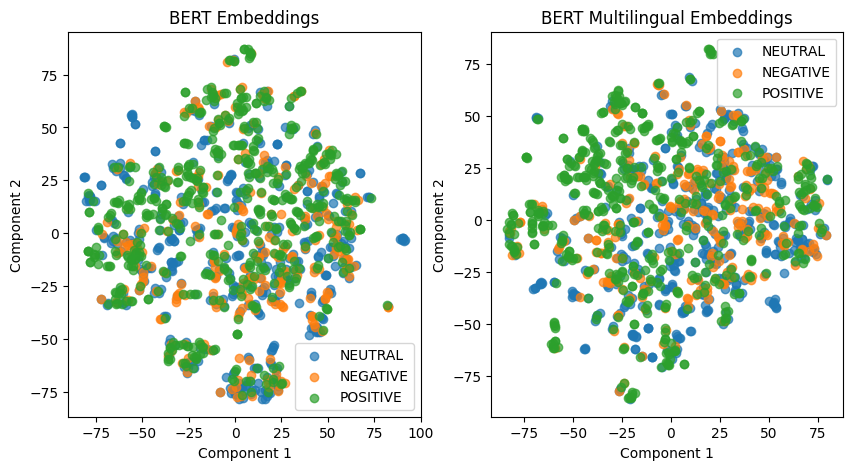

In [5]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

# Perform PCA on the embeddings
embeddings = np.load('bert_embeddings.npy')
embeddings_pt = np.load('bert_pt_embeddings.npy')

pca = TSNE(n_components=2, perplexity=5)
embeddings_pca = pca.fit_transform(embeddings)
pca_pt = TSNE(n_components=2, perplexity=5)
embeddings_pca_pt = pca_pt.fit_transform(embeddings_pt)

# Create a scatter plot
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
for sentiment in df['real_sentiment'].unique():
    indices = df['real_sentiment'] == sentiment
    plt.scatter(embeddings_pca[indices, 0], embeddings_pca[indices, 1], label=sentiment, alpha=0.7)

plt.title("BERT Embeddings")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()


plt.subplot(1, 2, 2)
for sentiment in df['real_sentiment'].unique():
    indices = df['real_sentiment'] == sentiment
    plt.scatter(embeddings_pca_pt[indices, 0], embeddings_pca_pt[indices, 1], label=sentiment, alpha=0.7)

plt.title("BERT Multilingual Embeddings")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(embeddings, df['real_sentiment'], test_size=0.2, random_state=42)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("BERT Original\n\n")
print(classification_report(y_test, y_pred))

print("\n\n--------------------------\n\n")

X_train_pt, X_test_pt, y_train_pt, y_test_pt = train_test_split(embeddings_pt, df['real_sentiment'], test_size=0.2, random_state=42)
clf_pt = LogisticRegression(max_iter=1000)
clf_pt.fit(X_train_pt, y_train_pt)
y_pred_pt = clf_pt.predict(X_test)
print("BERT Multilingue\n\n")
print(classification_report(y_test_pt, y_pred_pt))

BERT Original


              precision    recall  f1-score   support

    NEGATIVE       0.35      0.32      0.34        53
     NEUTRAL       0.61      0.60      0.61        98
    POSITIVE       0.69      0.73      0.71       107

    accuracy                           0.60       258
   macro avg       0.55      0.55      0.55       258
weighted avg       0.59      0.60      0.59       258



--------------------------


BERT Multilingue


              precision    recall  f1-score   support

    NEGATIVE       0.16      0.15      0.16        53
     NEUTRAL       0.50      0.01      0.02        98
    POSITIVE       0.42      0.80      0.55       107

    accuracy                           0.37       258
   macro avg       0.36      0.32      0.24       258
weighted avg       0.40      0.37      0.27       258



Analisando, primeiramente, o PCA, podemos observar que o espaço de embeddings do BERT original está claramente mais disperso em comparação ao espaço de embedding do BERT multilingue. Considerando que estamos utilizando uma base focada em comentários relacionados especificamente ao Ibovespa, é de se esperar que haja uma maior proximidade de significado entre as palavras. Essa similaridade pode explicar a diferença de agrupamento entre os embeddings do BERT multilingue e do BERT Original, pois, enquanto o BERT multilingue teve no seu treinamento palavras da língua portuguesa e consegue calcular com precisão a proximidade de tema (o que refletirá em valores próximos entre os embeddings), o BERT original não, fazendo com que encontre valores mais discrepantes entre os parâmetros dos embeddings.

Considerando os relatórios de classificação, notamos que o resultado foi diferente do esperado: O BERT original se saiu melhor que o BERT multilingue em quase todas as métricas.

Por que isso ocorre?

Uma hipótese é que, no contexto de análise de sentimento em comentários sobre o Ibovespa, a precisão no cálculo de parâmetros de similaridade de significado pode, na verdade, atrapalhar a tomada de decisão por parte do modelo. Como vimos nos gráficos PCA, o BERT multilingue construiu um espaço de embeddings muito mais concentrado, o que indica proximidade entre os valores dos parâmetros. Essa concentração, em termos de cálculo probabilístico, ocasionará, para o BERT multilingue, numa diferença marginal entre as probabilidades de se encaixar em cada rótulo, aumentando a chance de categorização incorreta. Assim, o BERT original se sobrassai porque passa a depender mais, comparativamente, do fator de distribuição de frequência das palavras do que proximidade de significado.

Além disso, o caráter técnico das discussões sobre o ibovespa - com poucos indicadores de sentimento - pode ser um fator para acentuar essa confusão de significado. O gráfico abaixo mostra que as palavras mais presentes nos comentários não contém features classicamente sentimentais (comentários como "bom", "ruim", "gostei", etc.), indicando que os comentários utilizam um linguajar mais técnico, baseado fortemente em indicadores e comparativos. Desta forma, a proximidade semântica aumenta e os parâmetros de embedding do modelo BERT multilingue ficam mais próximos. Porém, se nos baseássemos mais fortemente na frequência de palavras atreladas a rótulo, como o BERT original possivelmente faz neste contexto, facilmente perceberíamos que palavras como "alta" e "máxima" podem indicar comentários positivos, enquanto palavras como "cai" indicam comentários negativos.

Por fim, o último indício que corrobora para esta hipótese é que, em comparação aos modelos BERT original e BERT multilingue, o modelo Bag-of-words foi o que teve o maior "accuracy", ou acerto dos rótulos. Ou seja, a análise de frequência parece se sobressair à análise de contexto nessa situação.

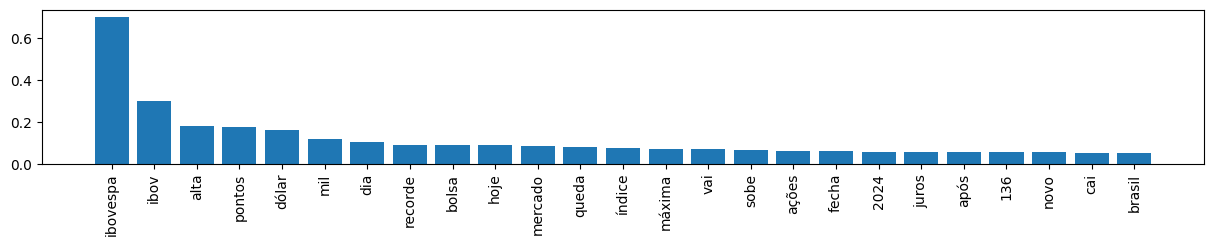

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import pandas as pd
import nltk

stopwords = nltk.corpus.stopwords.words('portuguese')

# Utilizaremos o CountVectorizer novamente para construir um dicionário de frequência de palavras no texto.
# A partir desse dicionário de frequência, teremos uma maior percepção de quais features são mais valorizadas nas reviews.
vectorizer = CountVectorizer(binary=True, stop_words=stopwords)
X = vectorizer.fit_transform(df['text'])

doc_freq_matrix = X.mean(axis=0)
doc_freq = {
    word: doc_freq_matrix[0, vectorizer.vocabulary_[word]]
    for word in vectorizer.vocabulary_
}

df_vocabulary = pd.DataFrame(doc_freq.items(), columns=['word', 'frequency'])
df_vocabulary = df_vocabulary.sort_values(by='frequency', ascending=False)
df_vocabulary.head()
plt.figure(figsize=(15,2))
plt.bar(df_vocabulary.iloc[0:25]['word'], df_vocabulary[0:25]['frequency'])
plt.xticks(rotation=90)
plt.show()